In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.  
`slk_prepare_data` standardises the perturbation column to `obs['pert']` with NTC → `'NTC'`.

In [3]:
data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep highly variable genes (seurat_v3, top 2000) **plus** any gene that appears as a perturbation target (single or split from combo) **plus** the top 10 DEGs (by |mean log-normalised expression − NTC|) for every perturbation. This reduces the feature space while ensuring every perturbed gene and its strongest downstream effects are retained.

In [4]:
top_deg = 10
# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# HVG selection on raw counts (seurat_v3 expects counts in X)
sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)

# Top-10 DEGs per perturbation (computed on log-normalised copy before subsetting)
_tmp = data.copy()
sc.pp.normalize_total(_tmp, target_sum=1e4)
sc.pp.log1p(_tmp)
X_norm = _tmp.X.toarray() if hasattr(_tmp.X, 'toarray') else _tmp.X
ntc_mean = X_norm[(_tmp.obs[p_key] == NTC).values].mean(axis=0)
deg_genes = set()
for p in all_perts:
    if p == NTC:
        continue
    mask = (_tmp.obs[p_key] == p).values
    if mask.sum() == 0:
        continue
    lfc = np.abs(X_norm[mask].mean(0) - ntc_mean)
    deg_genes.update(_tmp.var_names[np.argsort(lfc)[-top_deg:]])
del _tmp

# Union: HVG OR perturbation target OR top-10 DEG for any perturbation
pert_mask = data.var_names.isin(pert_genes)
deg_mask  = data.var_names.isin(deg_genes)
keep_mask = data.var['highly_variable'] | pert_mask #| deg_mask TODO ADD FOR DEG
data = data[:, keep_mask].copy()

n_hvg      = data.var['highly_variable'].sum()
n_pert_only = (pert_mask[keep_mask] & ~data.var['highly_variable']).sum()
n_deg_only  = (deg_mask[keep_mask] & ~data.var['highly_variable'] & ~pert_mask[keep_mask]).sum()
print(f"Kept {data.n_vars} genes  ({n_hvg} HVG + {n_pert_only} pert-only + {n_deg_only} DEG-only)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")

Kept 2040 genes  (2000 HVG + 40 pert-only + 0 DEG-only)
Pert genes in var_names: 102 / 105


## Compute treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC), computed for all labels including combinations.

In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f"treat_effect: {te.n_obs} perturbations × {te.n_vars} genes")
print(f"  single: {sum('+' not in p and p != NTC for p in te.obs_names)}   combo: {sum('+' in p for p in te.obs_names)}")

100%|██████████| 236/236 [00:03<00:00, 66.85it/s]

treat_effect: 236 perturbations × 2040 genes
  single: 105   combo: 131


## Train VAE (combinatorial mode)

Architecture:
- **Encoder** — background `z0` via `z0_encoder` on NTC; perturbed `z` via shared `z_encoder`
- **Gate** `W[p]` (HardConcrete, shape P×d) — sparse binary mask over latent dims
- **Shift** `z = z0*(1 − W[p]) + A[p]*W[p]` — mechanism shift only in gated dims (linear mode)
- **Decoder** — perturbation-agnostic NB decoder
- **Combinatorial** — labels like `GENE1+GENE2` are split; component shifts are summed at training time
- **Counterfactuals** — abduct NTC `z0`, K-means centroids, apply union(W) gate + Σ A_j*W_j shift

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

results = slk.tl.run_single(
    data,
    model='vae',
    # batch_size=2048,
    ce_lambda=1e-1,
    l0_lambda=5.,
    # l1_lambda=10.,
    rank=6,
    shuffle=True,
    num_workers=0,
    device=device,
    # latent_dim=16,
    num_epochs=500,
    validate_every=50,
    patience=20,
    combinatorial=True,
    debug=True,
    use_synergy=True
    # n_epochs_kl_warmup=20
)
model = results['model']

Device: cuda
Training VAE on cuda …


Epochs:   1%|          | 3/500 [00:08<24:32,  2.96s/it, ATE=nan, CE=nan, ELBO=1509.1257, KLw=0.06, R2_ntc=nan, R2_p=nan, acc=nan, pi25=nan, pi99=nan, tau=0.667]


KeyboardInterrupt: 

## Save & load

In [7]:
os.makedirs('../results', exist_ok=True)
slk.tl.save_results(results, '../results/norman_vae.pth')

In [7]:
model = slk.tl.load_results('../results/norman_vae.pth')
print(type(model))

<class 'sherlock.tools._models.VAE'>


## Evaluate

`z` — perturbed latent per cell.  
`rho_corr` — Pearson correlation of Cholesky-structured `A[p]` vectors.  
For z_corr, only single-perturbation cells are used.

In [205]:
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=device)
print(list(data.uns['results'].keys()))

['z_corr', 'z_perts', 'z_embed', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions', 'synergy']


classification
latent synergy candidate    64
mixed / ambiguous           46
dominance epistasis         21
Name: count, dtype: int64


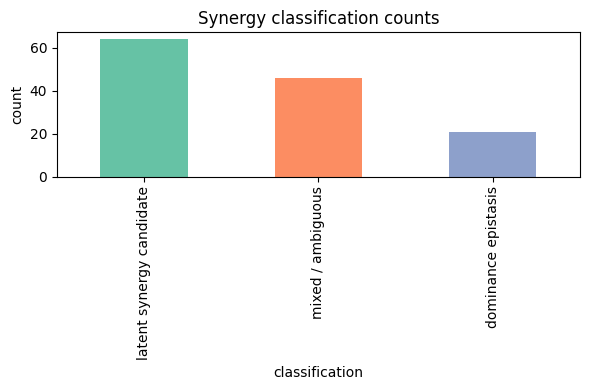

In [206]:
syn = data.uns['results']['synergy']
cls = syn['classification']
counts = cls.value_counts(dropna=False)

print(counts)

# quick bar plot
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', n_colors=len(counts)))
ax.set_ylabel('count')
ax.set_title("Synergy classification counts")
plt.tight_layout()
plt.show()

(<Axes: xlabel='dom_residual', ylabel='Count'>,
 <Axes: xlabel='dom_residual', ylabel='Count'>,
 <Axes: xlabel='dom_residual', ylabel='Count'>)

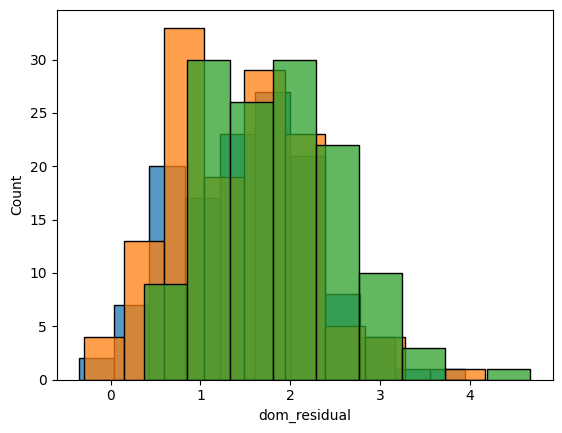

In [207]:
sns.histplot(syn['dom_residual']), sns.histplot(syn['proj_residual']), sns.histplot(syn['interaction_score'])

In [214]:
syn.to_csv('../results/norman_synergy.csv', index=False)
syn.head()

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,interaction_score,classification,proj_residual_z,dom_residual_z,interaction_score_z
AHR+FEV,AHR,FEV,None,558,703,276,0.457224,0.831468,0.860384,0.991024,3.021358,2.361451,3.148638,mixed / ambiguous,2.149396,1.134989,1.756524
AHR+KLF1,AHR,KLF1,KLF1,558,1954,481,0.010494,0.262350,0.953322,0.855135,1.281003,1.898692,2.020760,dominance epistasis,-0.174137,0.519985,0.243040
BAK1+BCL2L11,BAK1,BCL2L11,None,1451,582,175,0.121194,0.475576,0.292042,0.512613,0.062949,0.038480,0.639408,mixed / ambiguous,-1.800348,-1.952231,-1.610577
BAK1+KLF1,BAK1,KLF1,KLF1,1451,1954,392,-0.570031,-0.567319,0.996859,0.463203,0.767319,2.122375,2.159648,dominance epistasis,-0.859951,0.817259,0.429412
BAK1+TMSB4X,BAK1,TMSB4X,TMSB4X,1451,542,328,-0.060176,0.102857,0.977083,0.787701,0.742644,1.033324,1.076559,dominance epistasis,-0.892895,-0.630086,-1.023970


In [217]:
syn[syn.index.str.contains('ETS2')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,interaction_score,classification,proj_residual_z,dom_residual_z,interaction_score_z
CEBPE+ETS2,CEBPE,ETS2,None,1230,1201,354,0.539099,0.897785,0.832489,0.986204,1.209418,1.010161,1.385137,latent synergy candidate,-0.269709,-0.660870,-0.609894
CNN1+ETS2,CNN1,ETS2,None,765,1201,904,-0.470612,0.501945,0.509361,0.982835,0.797239,0.312365,0.899444,mixed / ambiguous,-0.820006,-1.588238,-1.261639
DUSP9+ETS2,DUSP9,ETS2,DUSP9,729,1201,786,-0.244707,0.961244,-0.011786,0.772508,0.440797,1.461021,1.647123,dominance epistasis,-1.295887,-0.061679,-0.258339
ETS2+IGDCC3,ETS2,IGDCC3,None,1201,613,441,-0.063684,0.414179,0.851994,0.925266,0.760261,1.088546,1.287165,mixed / ambiguous,-0.869374,-0.556696,-0.741361
ETS2+IKZF3,ETS2,IKZF3,None,1201,680,444,0.230774,0.429168,0.967669,0.890311,2.066024,2.705094,2.824452,mixed / ambiguous,0.873937,1.591690,1.321504
ETS2+MAP7D1,ETS2,MAP7D1,None,1201,751,324,0.271617,0.841773,0.693618,0.962777,1.924012,1.478007,2.106953,mixed / ambiguous,0.684339,-0.039105,0.358702
ETS2+MAPK1,ETS2,MAPK1,None,1201,763,459,0.995346,0.985790,0.992231,0.990163,1.994919,2.008474,2.124452,latent synergy candidate,0.779006,0.665884,0.382184
ETS2+PRTG,ETS2,PRTG,None,1201,684,445,-0.027665,0.336229,0.915345,0.897498,0.923024,1.463173,1.588894,mixed / ambiguous,-0.652071,-0.058819,-0.336475
ETS2+TGFBR2,ETS2,TGFBR2,ETS2,1201,644,318,-0.543703,0.943687,-0.334459,0.637736,0.525250,0.854562,1.020416,dominance epistasis,-1.183135,-0.867660,-1.099309


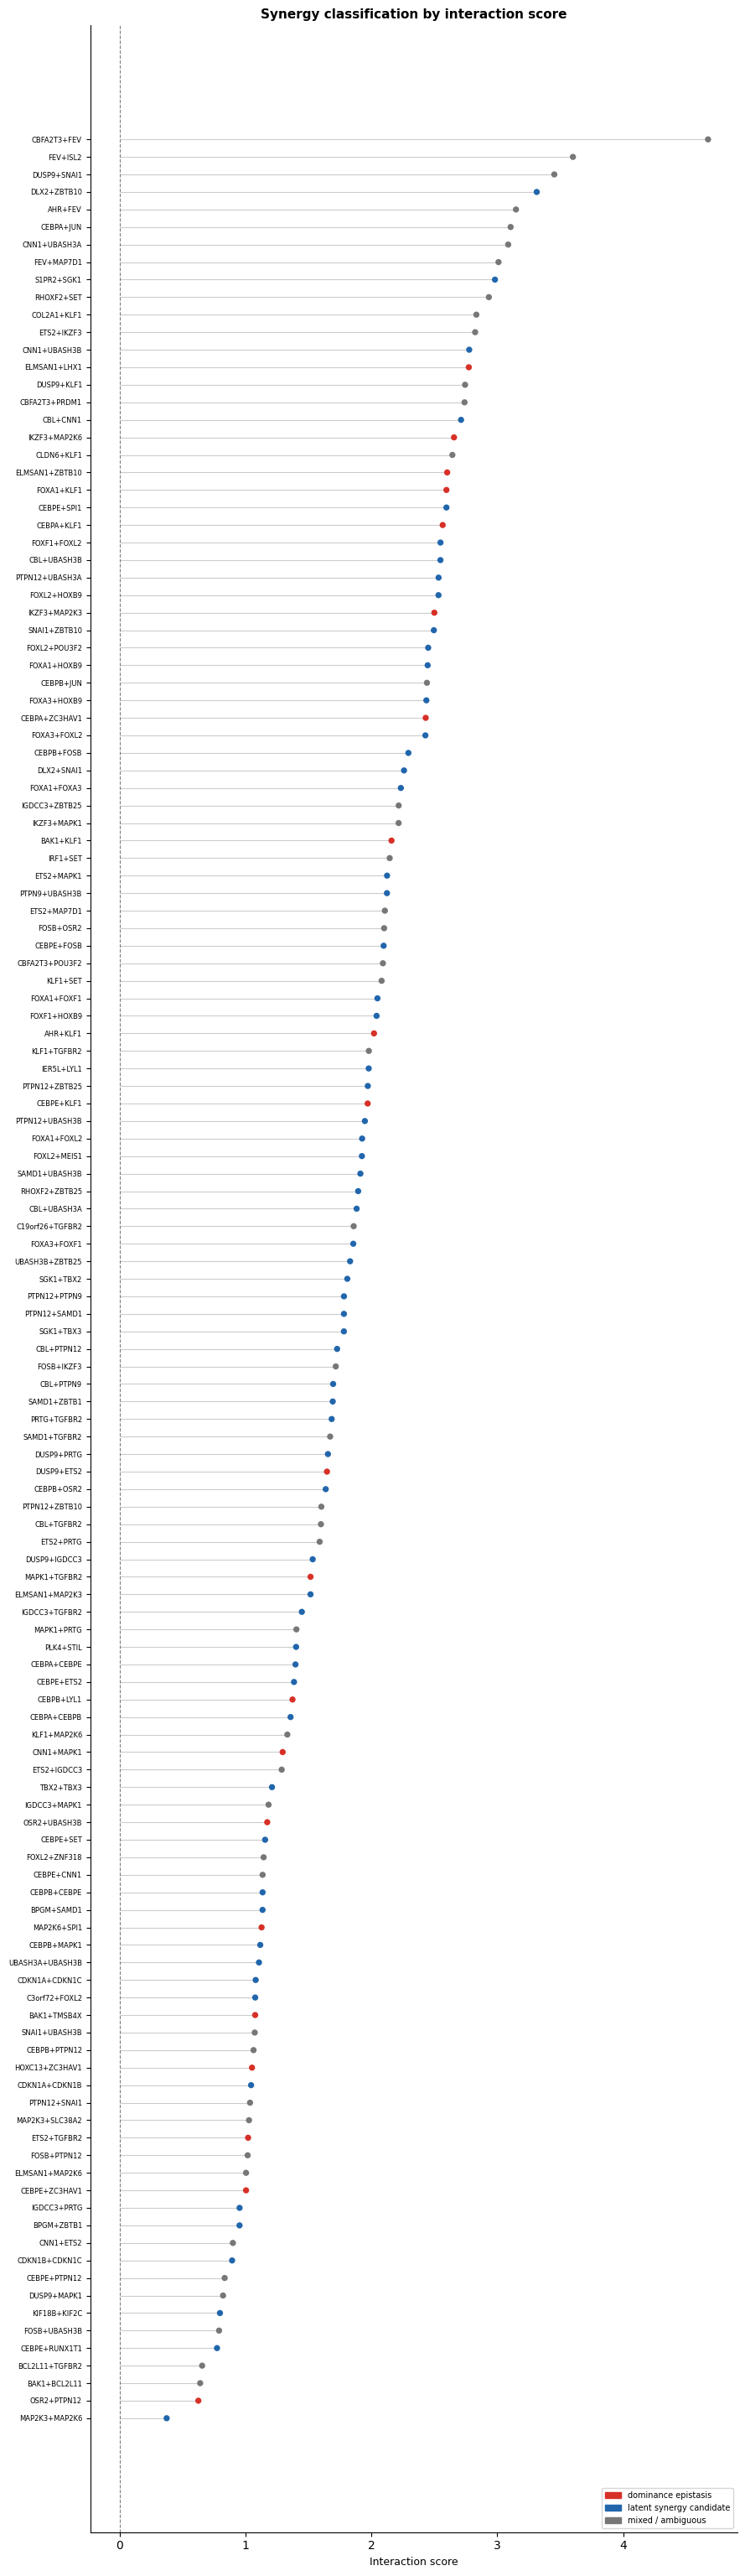

In [213]:
slk.pl.plot_synergy(data)

In [176]:
syn[syn.index.str.contains('CEBPE')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,classification
CEBPA+CEBPE,CEBPA,CEBPE,None,458,1230,179,0.940585,0.976683,0.942612,0.974228,0.588000,0.656556,latent synergy candidate
CEBPB+CEBPE,CEBPB,CEBPE,None,487,1230,114,0.913778,0.962594,0.956811,0.981083,0.619202,0.626433,latent synergy candidate
CEBPE+CNN1,CEBPE,CNN1,None,1230,765,237,-0.123278,0.851766,0.374085,0.925746,0.841226,0.806254,mixed / ambiguous
CEBPE+ETS2,CEBPE,ETS2,None,1230,1201,354,0.539099,0.897785,0.832489,0.986204,1.209418,1.010161,latent synergy candidate
CEBPE+FOSB,CEBPE,FOSB,None,1230,630,151,0.914676,0.975146,0.915240,0.966024,1.691545,1.767445,latent synergy candidate
CEBPE+KLF1,CEBPE,KLF1,KLF1,1230,1954,467,-0.217911,0.282131,0.842165,0.898955,0.792805,1.685829,dominance epistasis
CEBPE+PTPN12,CEBPE,PTPN12,None,1230,445,414,0.256227,0.879469,0.653903,0.967383,0.599585,0.408676,mixed / ambiguous
CEBPE+RUNX1T1,CEBPE,RUNX1T1,None,1230,777,1215,0.773240,0.980780,0.800618,0.945937,0.478281,0.522494,latent synergy candidate
CEBPE+SET,CEBPE,SET,None,1230,985,657,0.502840,0.759292,0.922648,0.970150,0.475535,0.730392,latent synergy candidate
CEBPE+SPI1,CEBPE,SPI1,None,1230,613,179,0.765521,0.930230,0.924458,0.987006,2.323156,2.263894,latent synergy candidate


## UMAP of perturbed latent z  (single perturbations only)

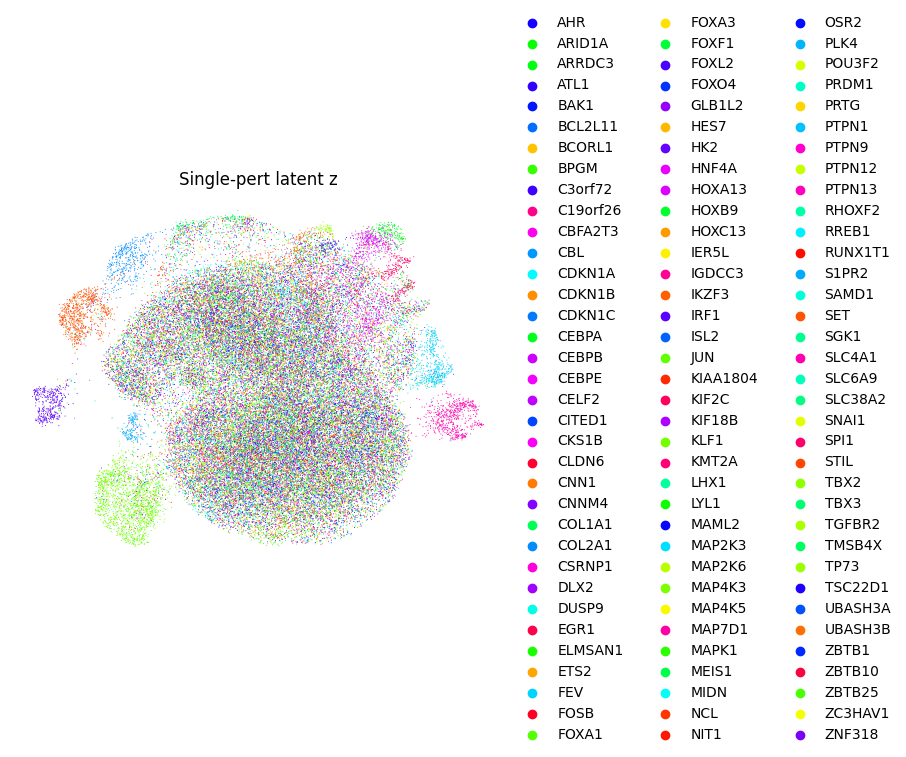

In [27]:
import random

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

n_cats  = sub.obs[p_key].nunique()
palette = sns.color_palette('hsv', n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color=p_key, palette=palette, frameon=False, title='Single-pert latent z')

## Perturbation embedding correlation (rho_corr)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


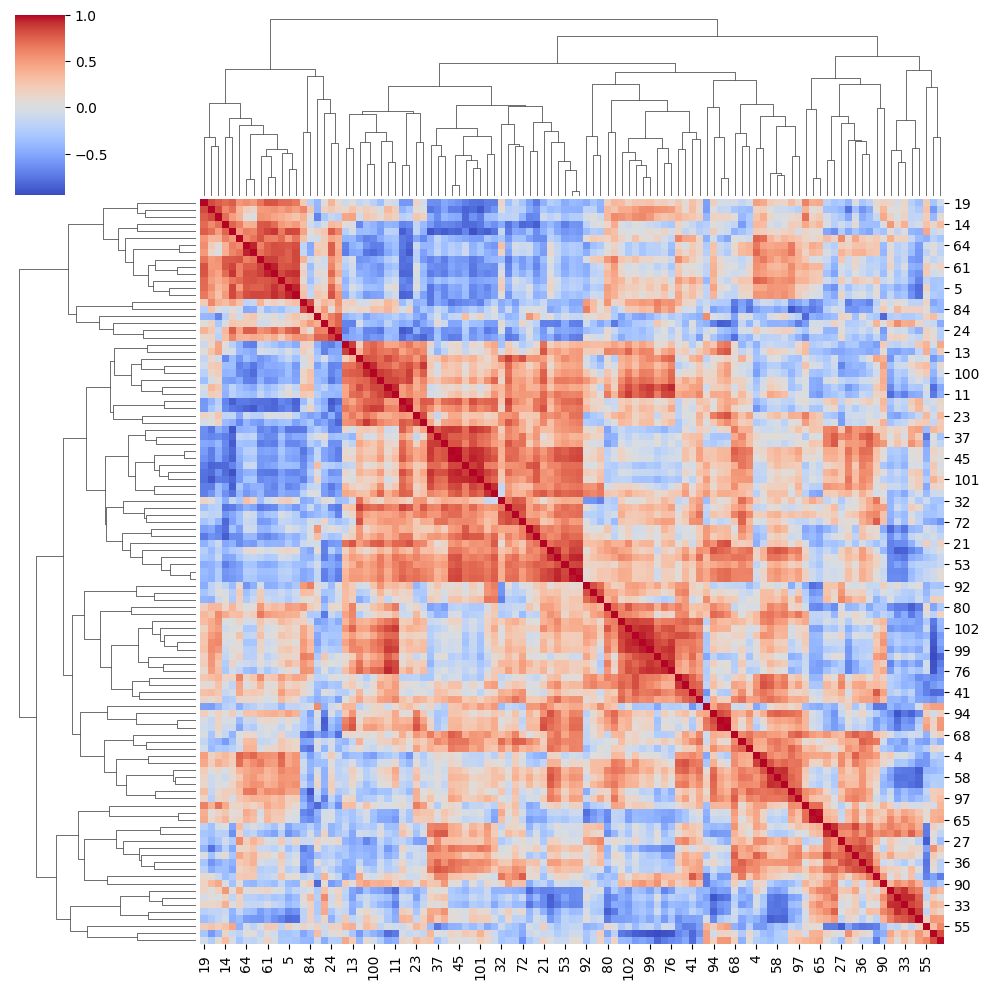

In [51]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

**Protocol**
1. Encode NTC cells → background `z0_i`
2. K-means centroids `c_k` in background space (K=25)
3. For each perturbation `p`:  
   — single: `z_cf = c_k * (1 − W[p]) + A[p]*W[p]`  
   — combo `A+B`: `z_cf = c_k * (1 − max(W_A, W_B)) + A_A*W_A + A_B*W_B`
4. Decode → expected counts, log2-CPM normalise, subtract NTC baseline
5. Pearson r vs observed `treat_effect`

In [52]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print(f"Pearson r (predicted vs observed ATE, all perts): {ate['corr']:.4f}")

Pearson r (predicted vs observed ATE, all perts): 0.6483


In [53]:
# Break down by single vs combo perturbations
from scipy.stats import pearsonr

pred_df = ate['predicted_df']
obs_df  = ate['observed_df']

single_idx = [p for p in pred_df.index if '+' not in str(p)]
combo_idx  = [p for p in pred_df.index if '+' in str(p)]

def _r(idx):
    if not idx:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return pearsonr(x[v], y[v])[0] if v.sum() > 2 else float('nan')

print(f"  Single perts ({len(single_idx):3d}): Pearson r = {_r(single_idx):.4f}")
print(f"  Combo  perts ({len(combo_idx):3d}): Pearson r = {_r(combo_idx):.4f}")

  Single perts (105): Pearson r = 0.5714
  Combo  perts (131): Pearson r = 0.6754


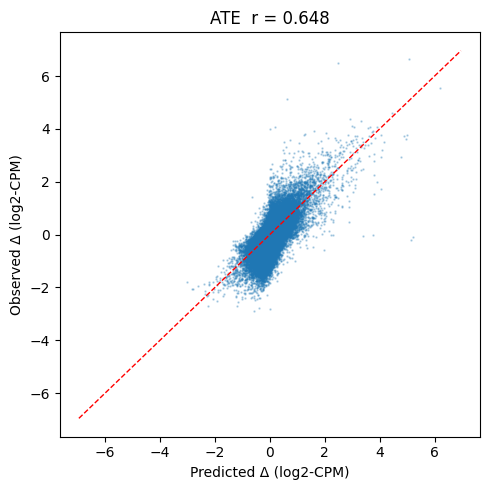

In [31]:
# Scatter: predicted vs observed ATE (all perts, flattened over genes)
x_flat = pred_df.values.ravel()
y_flat = obs_df.values.ravel()
valid  = np.isfinite(x_flat) & np.isfinite(y_flat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_flat[valid], y_flat[valid], s=0.5, alpha=0.3, rasterized=True)
lim = max(abs(x_flat[valid]).max(), abs(y_flat[valid]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlabel('Predicted Δ (log2-CPM)')
ax.set_ylabel('Observed Δ (log2-CPM)')
ax.set_title(f'ATE  r = {ate["corr"]:.3f}')
plt.tight_layout()
plt.show()

## z_corr vs rho_corr consistency

In [54]:
from scipy.stats import pearsonr, spearmanr

z_corr   = data.uns['results']['z_corr']
rho_corr = data.uns['results']['rho_corr']

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())
print(f"Spearman ρ = {spearman.statistic:.3f}  (p = {spearman.pvalue:.1e})")
print(f" Pearson  r = {pearson.statistic:.3f}  (p = {pearson.pvalue:.1e})")

Spearman ρ = 0.675  (p = 0.0e+00)
 Pearson  r = 0.689  (p = 0.0e+00)


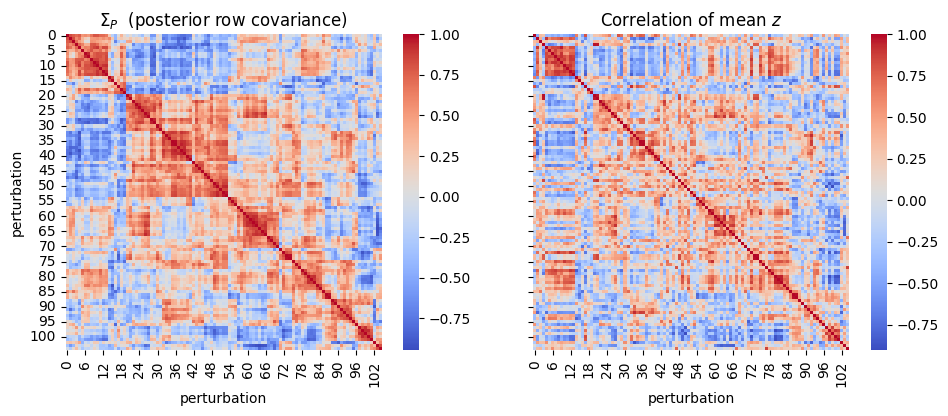

In [33]:
slk.pl.plot_zcorr(data)

## Gate W analysis

`W[p]` is a HardConcrete gate of shape `(P, d)`. Near-binary values indicate the model has learned sparse, perturbation-specific latent dimensions.

W shape: (105, 16)


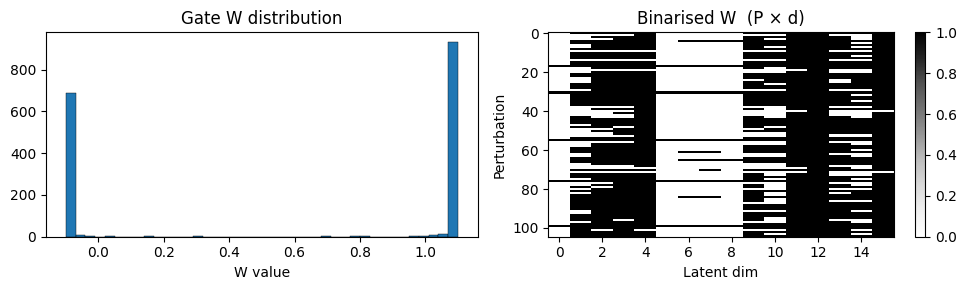

Avg active dims per pert: 9.2 / 16


In [55]:
W = data.uns['results']['W']   # (P, latent_dim)
print(f"W shape: {W.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(W.flatten(), bins=40, edgecolor='k', linewidth=0.3)
axes[0].set_title('Gate W distribution')
axes[0].set_xlabel('W value')

W_bin = (W > 0.5).astype(float)
im = axes[1].imshow(W_bin, aspect='auto', cmap='Greys', interpolation='nearest')
axes[1].set_title('Binarised W  (P × d)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Avg active dims per pert: {W_bin.sum(1).mean():.1f} / {W.shape[1]}")

## Perturbation clustering

Cluster `rho_corr` (correlation of learned `A[p]` vectors) and visualise groups on the single-pert UMAP.

In [57]:
rho_perts = data.uns['results']['rho_perts']
C = rho_corr
print(f"rho_corr: {C.shape}  |  perts: {len(rho_perts)}")

rho_corr: (105, 105)  |  perts: 105


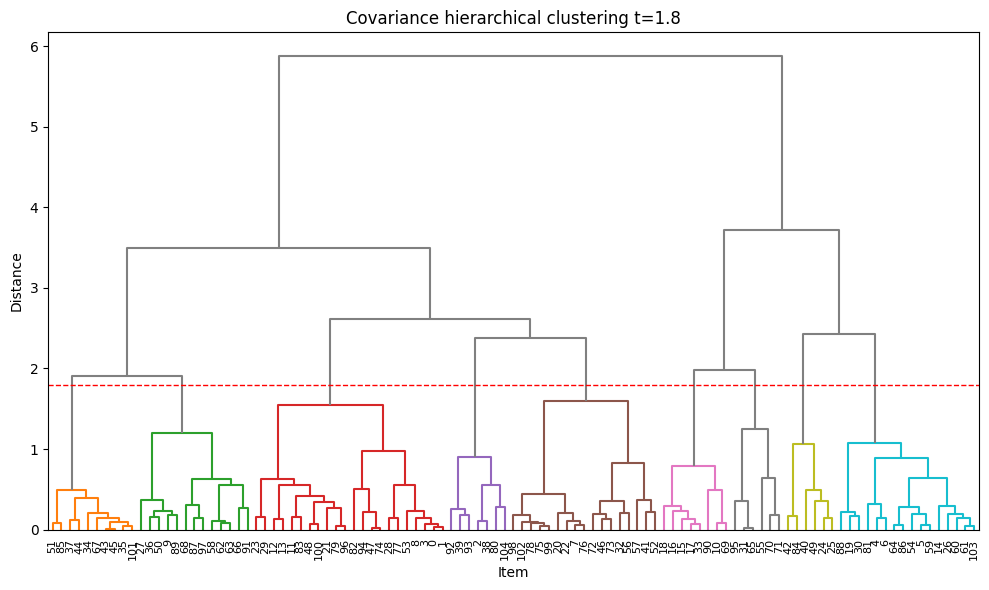

,group
AHR,3
ARID1A,3
ARRDC3,4
ATL1,3
BAK1,9
...,...
ZBTB1,3
ZBTB10,1
ZBTB25,5
ZC3HAV1,9


In [49]:
groups       = slk.tl.cluster_rho(data, t=1.8, rho_corr=C, show=True)
named_groups = slk.tl.group2name(groups, list(rho_perts))
named_groups

pert_group
1     4557
2     6828
3    11248
4     3530
5     8490
6     4741
7     5575
8     2698
9    10068
Name: count, dtype: int64


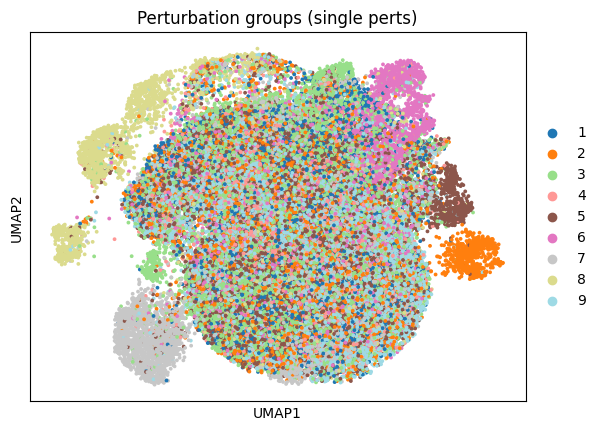

In [50]:
# Colour single-pert UMAP by learned perturbation group
gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

print(sub.obs['pert_group'].value_counts().sort_index())
sc.pl.umap(sub, color=['pert_group'], title='Perturbation groups (single perts)', palette='tab20', size=30)

## Synergy scoring

In [163]:
erythroid = [
    # Globins
    "HBA1", "HBA2", "HBB", "HBG1", "HBG2", "HBE1", "HBZ", "HBD",
    # Membrane/structural
    "GYPA", "GYPB", "GYPC", "SLC4A1", "EPB42", "EPB41",
    "ANK1", "SPTA1", "SPTB", "RHAG",
    # Heme synthesis
    "ALAS2", "ALAD", "HMBS", "UROS", "UROD", "CPOX", "PPOX", "FECH", "TMEM14C",
    # Iron/chaperone
    "AHSP", "TFRC", "SLC25A37", "STEAP3", "FTH1", "FTL",
    # Transcription factors
    "KLF1", "GATA1", "TAL1", "ZFPM1", "NFE2", "LMO2", "MYB",
    # Signaling
    "EPOR", "STAT5A",
    # Metabolism
    "CA1", "CA2", "PKLR", "BPGM", "KCNN4",
    # Maturation
    "BNIP3L",
]

myeloid = [
    "SPI1", "CEBPA", "CEBPB", "CEBPE",
    "MPO", "ELANE", "LYZ", "S100A8", "S100A9", "CSF3R"
]

ifn_stress = [
    "IRF1", "STAT1", "ISG15", "IFIT1", "IFIT2", "IFIT3",
    "MX1", "OAS1", "DDIT3", "HSPA1A"
]

proliferation = [
    "MKI67", "TOP2A", "PCNA", "MCM2", "MCM3", "MCM4",
    "MCM5", "MCM6", "MCM7"
]

gene_sets = {
    "erythroid": erythroid,
    "myeloid": myeloid,
    "ifn_stress": ifn_stress,
    "proliferation": proliferation,
}

for name, genes in gene_sets.items():
    genes = [g for g in genes if g in data.var_names]
    sc.tl.score_genes(data, genes, score_name=f"{name}_score")

In [208]:
import pandas as pd
import numpy as np

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

SYN_COLOR = '#2166ac'
EPI_COLOR = '#d73027'

# ── Synergy DataFrame — z-score residuals separately ──────────────────
syn = pd.DataFrame(data.uns['results']['synergy'])
pr  = syn['proj_residual'].values.astype(float)
dr  = syn['dom_residual'].values.astype(float)
ist = syn['interaction_score'].values.astype(float)
syn['proj_residual_z']    = (pr  - np.nanmean(pr))  / (np.nanstd(pr)  + 1e-10)
syn['dom_residual_z']     = (dr  - np.nanmean(dr))  / (np.nanstd(dr)  + 1e-10)
syn['interaction_score_z'] = (ist - np.nanmean(ist)) / (np.nanstd(ist) + 1e-10)

def _find_pair(df, a, b):
    for k in [f"{a}+{b}", f"{b}+{a}"]:
        if k in df.index:
            return k
    return None

required_syn_key = _find_pair(syn, 'CBL', 'CNN1')
required_epi_key = (_find_pair(syn, 'DUSP9', 'ETS1') or _find_pair(syn, 'DUSP9', 'ETS2'))

# Synergy: top proj_residual; Epistasis: top dom_residual
syn_cands = syn[syn['classification'] == 'latent synergy candidate']\
    .sort_values('proj_residual', ascending=False)
epi_cands = syn[syn['classification'] == 'dominance epistasis']\
    .sort_values('dom_residual', ascending=False)

def _build_list(required, pool, n=5):
    out = [required] if required and required in syn.index else []
    for idx in pool.index:
        if idx not in out and len(out) < n:
            out.append(idx)
    return out

syn_pairs    = _build_list(required_syn_key, syn_cands)
epi_pairs    = _build_list(required_epi_key, epi_cands)
selected     = syn_pairs + epi_pairs
selected_syn = set(syn_pairs)
selected_epi = set(epi_pairs)

print("Synergy pairs:  ", syn_pairs)
print("Epistatic pairs:", epi_pairs)

# ── NTC-centred deltas ─────────────────────────────────────────────────
z          = data.obsm['z']
pert_obs   = data.obs[p_key].astype(str).values
mean_z_ntc = z[pert_obs == NTC].mean(0)

def _delta(p):
    return z[pert_obs == p].mean(0) - mean_z_ntc


Synergy pairs:   ['CBL+CNN1', 'DLX2+ZBTB10', 'CNN1+UBASH3B', 'S1PR2+SGK1', 'CEBPE+SPI1']
Epistatic pairs: ['DUSP9+ETS2', 'ELMSAN1+LHX1', 'IKZF3+MAP2K6', 'ELMSAN1+ZBTB10', 'CEBPA+KLF1']


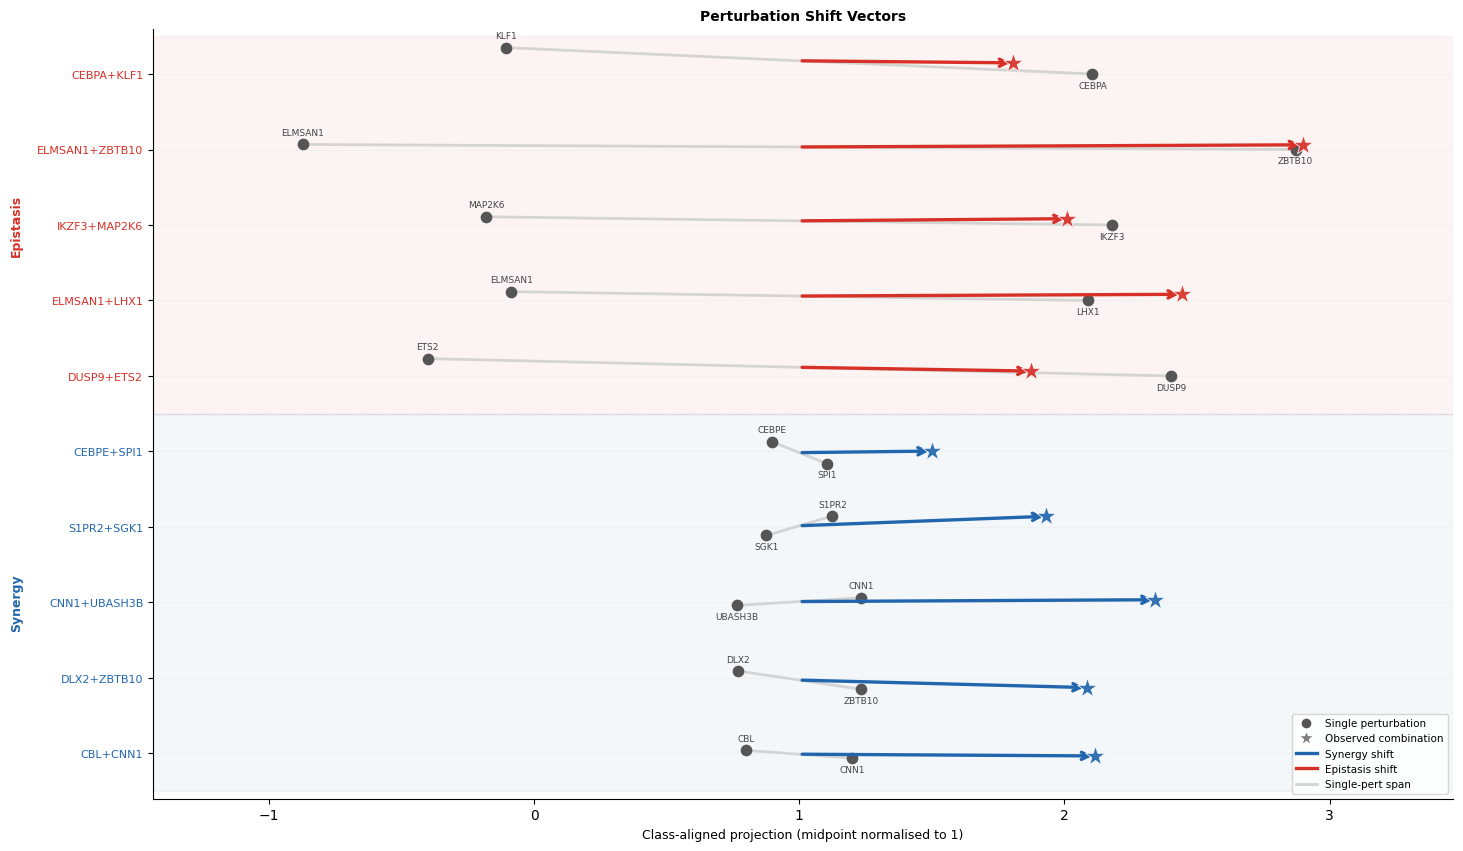

In [209]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_eps = 1e-8

def _unit(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    n = np.linalg.norm(x)
    return x / n if n > eps else None


def _decompose_full(da, db, dab, mode="shared", dominant_pert=None, pert_a=None, pert_b=None, eps=1e-8):
    ua = _unit(da, eps)
    ub = _unit(db, eps)
    if ua is None or ub is None:
        return None

    if mode == "dominant":
        if dominant_pert == pert_a:
            e1, other = ua, ub
        elif dominant_pert == pert_b:
            e1, other = ub, ua
        else:
            e1, other = _unit(ua + ub, eps), ua - ub
    else:
        e1, other = _unit(ua + ub, eps), ua - ub

    if e1 is None:
        return None

    e2_raw = other - np.dot(other, e1) * e1
    e2 = _unit(e2_raw, eps)
    if e2 is None:
        tmp = np.zeros_like(e1)
        tmp[np.argmin(np.abs(e1))] = 1.0
        e2 = _unit(tmp - np.dot(tmp, e1) * e1, eps)

    def _p(v):
        return float(np.dot(v, e1)), (float(np.dot(v, e2)) if e2 is not None else 0.0)

    de = 0.5 * (da + db)
    return dict(A=_p(da), B=_p(db), E=_p(de), AB=_p(dab),
                interaction_norm=float(np.linalg.norm(dab - de)))


pairs_ordered = syn_pairs + epi_pairs
n_syn   = len(syn_pairs)
n_pairs = len(pairs_ordered)

# Compute decompositions
row_data = []
for pair_key in pairs_ordered:
    row = syn.loc[pair_key]
    na, nb = row['pert_a'], row['pert_b']
    has_data = (pert_obs == na).any() and (pert_obs == nb).any() and (pert_obs == pair_key).any()
    if not has_data:
        row_data.append(None)
        continue
    mode = "dominant" if row['classification'] == "dominance epistasis" else "shared"
    row_data.append(_decompose_full(
        _delta(na), _delta(nb), _delta(pair_key),
        mode=mode, dominant_pert=row.get('dominant_pert'),
        pert_a=na, pert_b=nb, eps=_eps,
    ))

all_y_raw = [r[k][1] for r in row_data if r for k in ('A', 'B', 'E', 'AB')]
y_scale = 0.35 / (max((abs(v) for v in all_y_raw), default=1.0) + _eps)

fig, ax = plt.subplots(figsize=(20, max(6, n_pairs * 0.8 + 2)))

ax.axhspan(-0.5,        n_syn - 0.5,   alpha=0.05, color=SYN_COLOR, zorder=0)
ax.axhspan(n_syn - 0.5, n_pairs - 0.5, alpha=0.05, color=EPI_COLOR, zorder=0)
ax.axhline(n_syn - 0.5, color='#ccc', lw=0.8, linestyle=':', zorder=0)

x_all = []
for row_i, (pair_key, result) in enumerate(zip(pairs_ordered, row_data)):
    color = SYN_COLOR if pair_key in selected_syn else EPI_COLOR
    row   = syn.loc[pair_key]
    na, nb = row['pert_a'], row['pert_b']

    ax.axhline(row_i, color='#eee', lw=0.5, zorder=0)

    if result is None:
        ax.text(1.0, row_i, '(no data)', fontsize=7, ha='center', va='center', color='#aaa')
        continue

    e_x = result['E'][0]
    norm = abs(e_x) + _eps

    A_xn  = result['A'][0]  / norm
    B_xn  = result['B'][0]  / norm
    E_xn  = 1.0
    AB_xn = result['AB'][0] / norm

    A_yp  = row_i + result['A'][1]  * y_scale
    B_yp  = row_i + result['B'][1]  * y_scale
    E_yp  = row_i + result['E'][1]  * y_scale
    AB_yp = row_i + result['AB'][1] * y_scale

    x_all.extend([A_xn, B_xn, AB_xn])

    ax.plot([A_xn, B_xn], [A_yp, B_yp], '-', color='#d4d4d4', lw=2.0, zorder=1, solid_capstyle='round')
    ax.annotate('', xy=(AB_xn, AB_yp), xytext=(E_xn, E_yp),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.4, mutation_scale=13), zorder=4)
    ax.scatter(A_xn,  A_yp,  s=55,  c='#555', marker='o', zorder=3)
    ax.scatter(B_xn,  B_yp,  s=55,  c='#555', marker='o', zorder=3)
    ax.scatter(AB_xn, AB_yp, s=220, c=color,  marker='*', zorder=5,
               edgecolors='white', linewidths=0.6, alpha=0.92)

    va_a = 'bottom' if A_yp >= B_yp else 'top'
    va_b = 'top'    if A_yp >= B_yp else 'bottom'
    ax.annotate(na, (A_xn, A_yp), fontsize=6.5, ha='center', va=va_a,
                xytext=(0, 5 if va_a == 'bottom' else -5), textcoords='offset points', color='#444')
    ax.annotate(nb, (B_xn, B_yp), fontsize=6.5, ha='center', va=va_b,
                xytext=(0, -5 if va_b == 'top' else 5), textcoords='offset points', color='#444')

# Y-axis: just pair names
ax.set_yticks(range(n_pairs))
ax.set_yticklabels(pairs_ordered, fontsize=8)
for tick, pair_key in zip(ax.get_yticklabels(), pairs_ordered):
    tick.set_color(SYN_COLOR if pair_key in selected_syn else EPI_COLOR)

if x_all:
    lo, hi = min(x_all), max(x_all)
    pad = max((hi - lo) * 0.15, 0.3)
    ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(-0.6, n_pairs - 0.4)
ax.set_xlabel('Class-aligned projection (midpoint normalised to 1)', fontsize=9)
ax.set_title('Perturbation Shift Vectors', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Synergy / Epistasis labels — further left to clear y-tick labels
ax.text(-0.10, (n_syn - 1) / 2, 'Synergy',
        transform=ax.get_yaxis_transform(), fontsize=9, fontweight='bold',
        color=SYN_COLOR, ha='right', va='center', rotation=90)
ax.text(-0.10, n_syn + (n_pairs - n_syn - 1) / 2, 'Epistasis',
        transform=ax.get_yaxis_transform(), fontsize=9, fontweight='bold',
        color=EPI_COLOR, ha='right', va='center', rotation=90)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555', markersize=8,
           label='Single perturbation'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=12,
           label='Observed combination'),
    Line2D([0], [0], color=SYN_COLOR, lw=2.4, label='Synergy shift'),
    Line2D([0], [0], color=EPI_COLOR, lw=2.4, label='Epistasis shift'),
    Line2D([0], [0], color='#d4d4d4', lw=2.0, label='Single-pert span'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7.5, frameon=True)

fig.subplots_adjust(left=0.25)
plt.show()


In [147]:
syn[syn.index.str.contains('OSR2')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,classification,proj_residual_z
CEBPB+OSR2,CEBPB,OSR2,None,487,1002,211,0.518737,0.908942,0.811998,0.987437,1.474980,latent synergy candidate,0.084840
FOSB+OSR2,FOSB,OSR2,None,630,1002,382,0.435361,0.809426,0.876288,0.994920,2.068919,mixed / ambiguous,0.877802
OSR2+PTPN12,OSR2,PTPN12,OSR2,1002,445,338,-0.595607,0.837684,-0.138227,0.777757,0.096475,dominance epistasis,-1.755589
OSR2+UBASH3B,OSR2,UBASH3B,OSR2,1002,1201,795,-0.562060,0.968559,-0.508198,0.491900,-0.056332,dominance epistasis,-1.959601


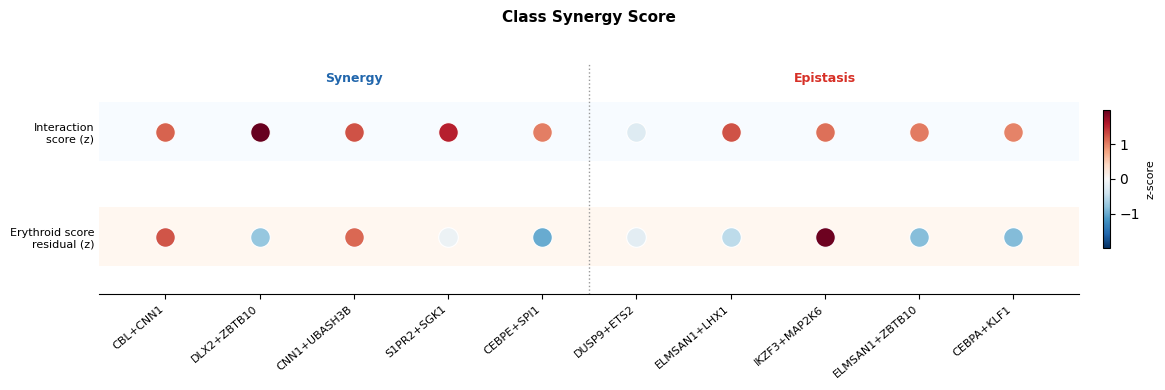

In [210]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

pairs       = [p for p in selected if p in syn.index]
n_pairs     = len(pairs)
n_syn_shown = sum(1 for p in pairs if p in selected_syn)

# ── Interaction score z-score (top row) ───────────────────────────────
interaction_z = np.array([float(syn.loc[p, 'interaction_score_z']) for p in pairs])

# ── Erythroid score residual (bottom row) ─────────────────────────────
ery_raw = np.full(n_pairs, np.nan)
for j, pair in enumerate(pairs):
    row = syn.loc[pair]
    na, nb = row['pert_a'], row['pert_b']
    mask_ab = data.obs[p_key] == pair
    mask_a  = data.obs[p_key] == na
    mask_b  = data.obs[p_key] == nb
    if mask_ab.any() and mask_a.any() and mask_b.any():
        ery_raw[j] = (
            data.obs.loc[mask_ab, 'erythroid_score'].mean()
            - 0.5 * (data.obs.loc[mask_a, 'erythroid_score'].mean()
                     + data.obs.loc[mask_b, 'erythroid_score'].mean())
        )

valid = np.isfinite(ery_raw)
if valid.sum() > 1:
    ery_z = (ery_raw - np.nanmean(ery_raw)) / (np.nanstd(ery_raw) + 1e-10)
else:
    ery_z = ery_raw.copy()

# ── Shared diverging colormap across both rows ─────────────────────────
all_z = np.concatenate([interaction_z[np.isfinite(interaction_z)], ery_z[np.isfinite(ery_z)]])
vabs  = float(np.abs(all_z).max()) if len(all_z) > 0 else 1.0
cmap  = plt.cm.RdBu_r
norm  = mcolors.Normalize(vmin=-vabs, vmax=vabs)

DOT_SIZE = 200
x_pos    = np.arange(n_pairs)

fig, ax = plt.subplots(figsize=(max(8, n_pairs * 1.1 + 2), 4))

# Row backgrounds
for y, c in [(1.0, '#f7fbff'), (0.0, '#fff7f0')]:
    ax.axhspan(y - 0.28, y + 0.28, color=c, zorder=0, lw=0)

# Synergy / epistasis divider
if 0 < n_syn_shown < n_pairs:
    ax.axvline(n_syn_shown - 0.5, color='#999', lw=1.0, linestyle=':', zorder=2)

# Top row: interaction score
for j, zv in enumerate(interaction_z):
    c = [cmap(norm(zv))] if np.isfinite(zv) else ['#ddd']
    ax.scatter(j, 1.0, s=DOT_SIZE, c=c, edgecolors='white', linewidths=0.8, zorder=3)

# Bottom row: erythroid score residual
for j, zv in enumerate(ery_z):
    c = [cmap(norm(zv))] if np.isfinite(zv) else ['#ddd']
    ax.scatter(j, 0.0, s=DOT_SIZE, c=c, edgecolors='white', linewidths=0.8, zorder=3)

# Section labels above top row
if n_syn_shown > 0:
    ax.text(n_syn_shown / 2 - 0.5, 1.45, 'Synergy',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=SYN_COLOR)
if n_syn_shown < n_pairs:
    ax.text(n_syn_shown + (n_pairs - n_syn_shown) / 2 - 0.5, 1.45, 'Epistasis',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=EPI_COLOR)

ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['Erythroid score\nresidual (z)', 'Interaction\nscore (z)'], fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(pairs, rotation=40, ha='right', fontsize=8)
ax.set_xlim(-0.7, n_pairs - 0.3)
ax.set_ylim(-0.55, 1.65)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('z-score', fontsize=8)

ax.set_title('Class Synergy Score', fontsize=11, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()


In [211]:
syn[syn.index.str.contains('DUSP9')]

,pert_a,pert_b,dominant_pert,n_a,n_b,n_ab,cos_a_b,cos_ab_a,cos_ab_b,cos_ab_shared,proj_residual,dom_residual,interaction_score,classification,proj_residual_z,dom_residual_z,interaction_score_z
DUSP9+ETS2,DUSP9,ETS2,DUSP9,729,1201,786,-0.244707,0.961244,-0.011786,0.772508,0.440797,1.461021,1.647123,dominance epistasis,-1.295887,-0.061679,-0.258339
DUSP9+IGDCC3,DUSP9,IGDCC3,None,729,613,382,0.535926,0.903552,0.830651,0.989464,1.422022,1.300323,1.533467,latent synergy candidate,0.014136,-0.275245,-0.410851
DUSP9+KLF1,DUSP9,KLF1,None,729,1954,366,0.053323,0.653812,0.756149,0.971430,2.416852,2.024684,2.744447,mixed / ambiguous,1.342324,0.687427,1.214145
DUSP9+MAPK1,DUSP9,MAPK1,None,729,763,290,-0.264993,0.714772,0.413991,0.930983,-0.299227,0.078752,0.821201,mixed / ambiguous,-2.283887,-1.898709,-1.366632
DUSP9+PRTG,DUSP9,PRTG,None,729,684,297,0.518618,0.881748,0.854415,0.996211,1.605561,1.392356,1.654632,latent synergy candidate,0.259178,-0.152935,-0.248263
DUSP9+SNAI1,DUSP9,SNAI1,None,729,466,182,0.277514,0.733017,0.811169,0.966055,3.010686,2.961030,3.453320,mixed / ambiguous,2.135147,1.931828,2.165374


<Axes: xlabel='dom_residual', ylabel='Count'>

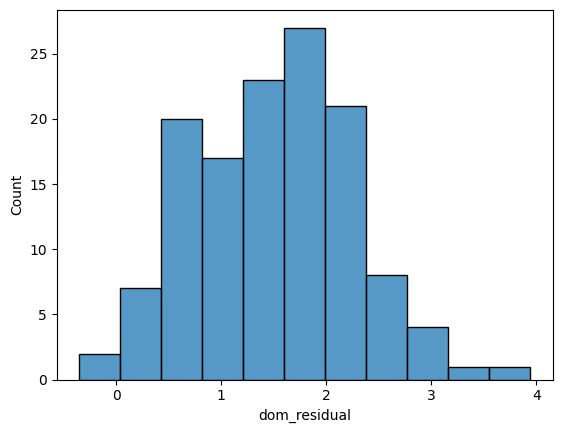

In [187]:
sns.histplot(syn['dom_residual'])